In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
!pip install torchinfo

In [ ]:
# ===============================
# 0. IMPORTS
# ===============================
import os, shutil, zipfile, random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp  # <--- WE WILL USE THIS NOW

In [ ]:
# ===============================
# 1. SEED & DEVICE
# ===============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [ ]:

# ===============================
# 3. UPGRADED DATASET CLASS
# ===============================
class GlaucomaDataset(Dataset):
    def __init__(self, img_dir, disc_dir, cup_dir, transform=None):
        self.img_dir = img_dir
        self.disc_dir = disc_dir
        self.cup_dir  = cup_dir
        self.transform = transform
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png','.jpg','.jpeg'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        # 1. Load Image
        image_path = os.path.join(self.img_dir, img_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 2. Fix Filename
        base_name = os.path.splitext(img_name)[0]
        mask_name = base_name + ".png"

        disc_path = os.path.join(self.disc_dir, mask_name)
        cup_path  = os.path.join(self.cup_dir, mask_name)

        # 3. Load Masks (Keep original size here!)
        disc_mask = cv2.imread(disc_path, cv2.IMREAD_GRAYSCALE)
        cup_mask  = cv2.imread(cup_path, cv2.IMREAD_GRAYSCALE)

        if disc_mask is None or cup_mask is None:
            raise FileNotFoundError(f"Missing mask for {img_name}")

        # --- KEY FIX: MERGE FIRST, RESIZE LATER ---
        # We merge masks at original resolution to avoid resize artifacts
        mask = np.zeros(disc_mask.shape, dtype=np.uint8)

        # Order matters: Cup (2) overwrites Disc (1) where they overlap
        mask[disc_mask > 127] = 1
        mask[cup_mask  > 127] = 2

        # 4. Apply Augmentations (Let Albumentations handle the Resize!)
        if self.transform:
            # Albumentations automatically uses Nearest Neighbor for masks
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]

        return image, torch.as_tensor(mask).long()

In [ ]:
# ===============================
# 9. UTILS (Dice Score)
# ===============================
def dice_score(pred, target, cls):
    pred_bin   = (pred == cls).astype(np.uint8)
    target_bin = (target == cls).astype(np.uint8)
    intersection = np.sum(pred_bin * target_bin)
    union = np.sum(pred_bin) + np.sum(target_bin)
    if union == 0: return 1.0
    return (2.0 * intersection) / union

In [ ]:
# ===============================
# 10. TRAINING LOOP (Updated)
# ===============================
def validate(model, loader, device):
    model.eval()
    val_loss = 0.0
    dice_disc, dice_cup = [], []

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            masks = masks.cpu().numpy()

            for i in range(preds.shape[0]):
                dice_disc.append(dice_score(preds[i], masks[i], cls=1))
                dice_cup.append(dice_score(preds[i], masks[i], cls=2))

    return val_loss/len(loader), np.mean(dice_disc), np.mean(dice_cup)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


In [ ]:
class UNet(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        self.dropout = nn.Dropout(p=0.5)

        # Decoder
        self.up4  = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Output
        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b  = self.bottleneck(self.pool(e4))
        b  = self.dropout(b)

        # Decoder
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)  # logits


In [ ]:
model = UNet(n_classes=3).to(DEVICE)

In [ ]:
model

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc4): DoubleConv(
    (block): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(5

In [ ]:
from torchinfo import summary
summary(model, input_size=(1, 3, 512, 512))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 3, 512, 512]          --
├─DoubleConv: 1-1                        [1, 64, 512, 512]         --
│    └─Sequential: 2-1                   [1, 64, 512, 512]         --
│    │    └─Conv2d: 3-1                  [1, 64, 512, 512]         1,792
│    │    └─ReLU: 3-2                    [1, 64, 512, 512]         --
│    │    └─Conv2d: 3-3                  [1, 64, 512, 512]         36,928
│    │    └─ReLU: 3-4                    [1, 64, 512, 512]         --
├─MaxPool2d: 1-2                         [1, 64, 256, 256]         --
├─DoubleConv: 1-3                        [1, 128, 256, 256]        --
│    └─Sequential: 2-2                   [1, 128, 256, 256]        --
│    │    └─Conv2d: 3-5                  [1, 128, 256, 256]        73,856
│    │    └─ReLU: 3-6                    [1, 128, 256, 256]        --
│    │    └─Conv2d: 3-7                  [1, 128, 256, 256]        147,584

In [ ]:
model.load_state_dict(torch.load('/content/New_Architecture_the_best_ep16_D0.791_C0.745.pth'))

<All keys matched successfully>

# testing Refuge

In [ ]:
import requests
import os
import zipfile

reg=requests.get("https://www.kaggle.com/api/v1/datasets/download/victorlemosml/refuge2")
if os.path.exists('refuge2'):
  print("folder already exists")
else:
  print("folder does not exist")
  with open('refuge2.zip', 'wb') as f:
      f.write(reg.content)
  with zipfile.ZipFile('refuge2.zip', 'r') as zip_ref:
          zip_ref.extractall('refuge2')

folder does not exist


In [ ]:
import os
import cv2
import numpy as np
from scipy.ndimage import binary_fill_holes
from tqdm import tqdm

# ===============================
# PATHS (EDIT ONLY THIS)
# ===============================
ROOT_DIR = "/content/refuge2/REFUGE2"          # root dataset
OUTPUT_DIR = "processed"      # output folder

# ===============================
# CREATE OUTPUT FOLDERS
# ===============================
os.makedirs(os.path.join(OUTPUT_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "cup_masks"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "disc_masks"), exist_ok=True)

# ===============================
# PROCESS FUNCTION
# ===============================
def process_split(split_name):
    print(f"\nProcessing {split_name} set...")

    img_dir = os.path.join(ROOT_DIR, split_name, "images")
    mask_dir = os.path.join(ROOT_DIR, split_name, "mask")

    img_files = sorted(os.listdir(img_dir))

    for img_name in tqdm(img_files):
        name = os.path.splitext(img_name)[0]

        # ---------------------------
        # READ FUNDUS IMAGE (JPG)
        # ---------------------------
        img_path = os.path.join(img_dir, img_name)
        image = cv2.imread(img_path)

        if image is None:
            continue

        # ---------------------------
        # FIND MASK (BMP or PNG)
        # ---------------------------
        mask_path = None
        for ext in [".bmp", ".png"]:
            candidate = os.path.join(mask_dir, name + ext)
            if os.path.exists(candidate):
                mask_path = candidate
                break

        if mask_path is None:
            continue

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # ---------------------------
        # DISC MASK (GRAY REGION)
        # ---------------------------
        disc_binary = (mask > 50) & (mask < 200)
        disc_filled = binary_fill_holes(disc_binary)
        disc_mask = (disc_filled * 255).astype(np.uint8)

        # ---------------------------
        # CUP MASK (BLACK INSIDE DISC)
        # ---------------------------
        cup_binary = (mask == 0) & disc_filled
        cup_filled = binary_fill_holes(cup_binary)
        cup_mask = (cup_filled * 255).astype(np.uint8)

        # ---------------------------
        # SAVE OUTPUTS AS JPG
        # ---------------------------
        cv2.imwrite(os.path.join(OUTPUT_DIR, "images", name + ".jpg"), image)
        cv2.imwrite(os.path.join(OUTPUT_DIR, "cup_masks", name + ".jpg"), cup_mask)
        cv2.imwrite(os.path.join(OUTPUT_DIR, "disc_masks", name + ".jpg"), disc_mask)


# ===============================
# RUN PIPELINE
# ===============================
for split in ["train", "val", "test"]:
    process_split(split)

print("\n✅ Preprocessing complete!")



Processing train set...


100%|██████████| 400/400 [03:31<00:00,  1.89it/s]



Processing val set...


100%|██████████| 400/400 [02:53<00:00,  2.30it/s]



Processing test set...


100%|██████████| 400/400 [02:04<00:00,  3.22it/s]


✅ Preprocessing complete!


In [ ]:
LOCAL_BASE = "/content/processed"
LOCAL_IMG_DIR  = '/content/processed/images'
LOCAL_DISC_DIR = '/content/processed/disc_masks'
LOCAL_CUP_DIR  = '/content/processed/cup_masks'

In [ ]:

# ===============================
# 2. CDR CALCULATION FUNCTION
# ===============================
def calculate_vertical_cdr(mask_arr):
    """
    Calculates Vertical Cup-to-Disc Ratio (CDR).
    mask_arr: 2D numpy array with 0=BG, 1=Disc, 2=Cup
    """
    # Extract Disc and Cup pixels
    disc_pixels = np.argwhere(mask_arr == 1)
    cup_pixels  = np.argwhere(mask_arr == 2)

    # Check if we actually found pixels (safety check)
    if len(disc_pixels) == 0:
        return 0.0, 0.0, 0.0  # Model failed to find Disc

    # Get Vertical Heights (Max Row - Min Row)
    # Note: In a combined mask, Cup (2) is *inside* Disc.
    # Usually Disc mask includes the Cup area logically,
    # but in your pixel values 2 overwrites 1.
    # So True Disc Area = (Pixels==1) + (Pixels==2)

    # 1. Calculate Disc Height (Include Cup pixels as part of Disc)
    all_disc_pixels = np.argwhere(mask_arr > 0)
    disc_min_y, disc_max_y = all_disc_pixels[:, 0].min(), all_disc_pixels[:, 0].max()
    disc_height = disc_max_y - disc_min_y

    # 2. Calculate Cup Height
    if len(cup_pixels) == 0:
        cup_height = 0
    else:
        cup_min_y, cup_max_y = cup_pixels[:, 0].min(), cup_pixels[:, 0].max()
        cup_height = cup_max_y - cup_min_y

    # 3. Calculate CDR
    if disc_height == 0: return 0.0 # Avoid division by zero
    cdr = cup_height / disc_height

    return cdr, cup_height, disc_height

In [ ]:
# ===============================
# 4. PREPROCESSING (Must match Training!)
# ===============================
import os
import cv2
import torch
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512
import albumentations as A
from albumentations.pytorch import ToTensorV2

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

# ... (Include your imports and device setup if not already done above) ...

# ===============================
# 5. RUN COMBINED EVALUATION LOOP
# ===============================
results_06 = [] # Equivalent to your 'results'
results_05 = [] # Equivalent to your 'results2'

test_files = sorted(os.listdir(LOCAL_IMG_DIR))

print(f"Testing on {len(test_files)} images for both thresholds...")

for img_name in tqdm(test_files):
    if not img_name.endswith(('.png', '.jpg', '.jpeg')): continue

    # --- A. Load & Preprocess Image (DONE ONCE) ---
    img_path = os.path.join(LOCAL_IMG_DIR, img_name)
    image_src = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image_src, cv2.COLOR_BGR2RGB)

    transformed = test_transform(image=image_rgb)["image"].unsqueeze(0).to(DEVICE)

    # --- B. Load Ground Truth Masks (DONE ONCE) ---
    base_name = os.path.splitext(img_name)[0]
    mask_name = base_name + ".jpg" # Changed to .jpg as per processing

    disc_gt = cv2.imread(os.path.join(LOCAL_DISC_DIR, mask_name), 0)
    cup_gt  = cv2.imread(os.path.join(LOCAL_CUP_DIR, mask_name), 0)

    # Resize GT to 512x512 to match prediction scale
    disc_gt = cv2.resize(disc_gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    cup_gt  = cv2.resize(cup_gt, (IMG_SIZE, IMG_SIZE),  interpolation=cv2.INTER_NEAREST)

    # Merge GT into one mask
    gt_mask = np.zeros_like(disc_gt)
    gt_mask[disc_gt > 127] = 1
    gt_mask[cup_gt > 127]  = 2

    # --- C. Model Prediction (DONE ONCE - HUGE SAVING) ---
    with torch.no_grad():
        logits = model(transformed)
        pred_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

    # --- D. Calculate CDRs (DONE ONCE) ---
    pred_cdr, _, _ = calculate_vertical_cdr(pred_mask)
    gt_cdr, _, _   = calculate_vertical_cdr(gt_mask)

    # --- E1. Logic for Threshold 0.6 ---
    pred_glaucoma_06 = "Yes" if pred_cdr > 0.6 else "No"
    gt_glaucoma_06   = "Yes" if gt_cdr > 0.6 else "No"

    results_06.append({
        "Image": img_name,
        "GT_CDR": round(gt_cdr, 3),
        "Pred_CDR": round(pred_cdr, 3),
        "Diff (Error)": round(abs(gt_cdr - pred_cdr), 3),
        "GT_Diagnosis": gt_glaucoma_06,
        "Pred_Diagnosis": pred_glaucoma_06,
        "Correct?": pred_glaucoma_06 == gt_glaucoma_06
    })

    # --- E2. Logic for Threshold 0.5 ---
    pred_glaucoma_05 = "Yes" if pred_cdr > 0.5 else "No"
    gt_glaucoma_05   = "Yes" if gt_cdr > 0.5 else "No"

    results_05.append({
        "Image": img_name,
        "GT_CDR": round(gt_cdr, 3),
        "Pred_CDR": round(pred_cdr, 3),
        "Diff (Error)": round(abs(gt_cdr - pred_cdr), 3),
        "GT_Diagnosis": gt_glaucoma_05,
        "Pred_Diagnosis": pred_glaucoma_05,
        "Correct?": pred_glaucoma_05 == gt_glaucoma_05
    })

Testing on 1200 images for both thresholds...


100%|██████████| 1200/1200 [02:19<00:00,  8.58it/s]


In [ ]:

# ===============================
# 6. SHOW & SAVE RESULTS FOR 0.6
# ===============================
df_06 = pd.DataFrame(results_06)
mae_06 = df_06["Diff (Error)"].mean()
acc_06 = df_06["Correct?"].mean() * 100

print("\n" + "="*40)
print(f"RESULTS FOR THRESHOLD 0.6")
print("="*40)
print(f"Mean Absolute Error (CDR): {mae_06:.4f}")
print(f"Glaucoma Diagnosis Accuracy: {acc_06:.2f}%")
print("="*40)
df_06.to_csv("cdr_results_thresh06_final20epoch.csv", index=False)
print("Saved 0.6 results.")




RESULTS FOR THRESHOLD 0.6
Mean Absolute Error (CDR): 0.0892
Glaucoma Diagnosis Accuracy: 88.00%
Saved 0.6 results.


In [ ]:
# ===============================
# 7. SHOW & SAVE RESULTS FOR 0.5
# ===============================
df_05 = pd.DataFrame(results_05)
mae_05 = df_05["Diff (Error)"].mean()
acc_05 = df_05["Correct?"].mean() * 100

print("\n" + "="*40)
print(f"RESULTS FOR THRESHOLD 0.5")
print("="*40)
print(f"Mean Absolute Error (CDR): {mae_05:.4f}")
print(f"Glaucoma Diagnosis Accuracy: {acc_05:.2f}%")
print("="*40)
df_05.to_csv("cdr_results_thresh05_final20epoch.csv", index=False)
print("Saved 0.5 results.")


RESULTS FOR THRESHOLD 0.5
Mean Absolute Error (CDR): 0.0892
Glaucoma Diagnosis Accuracy: 67.42%
Saved 0.5 results.


In [ ]:
# =========================================================
# 4. RUN EVALUATION LOOP
# =========================================================
results_06 = []
results_05 = []

# Assuming 'model' and 'test_transform' are already defined in your notebook
# model.to(DEVICE)
# model.eval()

test_files = sorted(os.listdir(LOCAL_IMG_DIR))
print(f"\nEvaluating on {len(test_files)} images...")

for img_name in tqdm(test_files):
    base_name = os.path.splitext(img_name)[0]

    # Load Processed Data
    img_path = os.path.join(LOCAL_IMG_DIR, img_name)
    image_src = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image_src, cv2.COLOR_BGR2RGB)

    disc_gt = cv2.imread(os.path.join(LOCAL_DISC_DIR, base_name + ".jpg"), 0)
    cup_gt  = cv2.imread(os.path.join(LOCAL_CUP_DIR, base_name + ".jpg"), 0)

    # Resize GT to match model output
    disc_gt = cv2.resize(disc_gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    cup_gt  = cv2.resize(cup_gt, (IMG_SIZE, IMG_SIZE),  interpolation=cv2.INTER_NEAREST)

    # Merge GT into one mask (1=disc, 2=cup)
    gt_mask = np.zeros_like(disc_gt)
    gt_mask[disc_gt > 127] = 1
    gt_mask[cup_gt > 127]  = 2

    # Model Prediction
    transformed = test_transform(image=image_rgb)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(transformed)
        pred_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

    # Calculate CDRs
    pred_cdr, _, _ = calculate_vertical_cdr(pred_mask)
    gt_cdr, _, _   = calculate_vertical_cdr(gt_mask)

    # Thresholding Logic
    for threshold, res_list in zip([0.6, 0.5], [results_06, results_05]):
        pred_diag = "Yes" if pred_cdr > threshold else "No"
        gt_diag   = "Yes" if gt_cdr > threshold else "No"
        res_list.append({
            "Image": img_name,
            "GT_CDR": round(gt_cdr, 3),
            "Pred_CDR": round(pred_cdr, 3),
            "Correct?": pred_diag == gt_diag
        })


Evaluating on 1200 images...


100%|██████████| 1200/1200 [02:11<00:00,  9.14it/s]


In [ ]:
# =========================================================
# 6. SHOW & SAVE RESULTS FOR 0.6
# =========================================================
df_06 = pd.DataFrame(results_06)

# Ensure the 'Diff (Error)' column exists for the calculation
if "Diff (Error)" not in df_06.columns:
    df_06["Diff (Error)"] = (df_06["GT_CDR"] - df_06["Pred_CDR"]).abs()

mae_06 = df_06["Diff (Error)"].mean()
acc_06 = df_06["Correct?"].mean() * 100

print("\n" + "="*40)
print(f"RESULTS FOR THRESHOLD 0.6")
print("="*40)
print(f"Mean Absolute Error (CDR): {mae_06:.4f}")
print(f"Glaucoma Diagnosis Accuracy: {acc_06:.2f}%")
print("="*40)

df_06.to_csv("cdr_results_thresh06_final20epoch.csv", index=False)
print("Saved 0.6 results to CSV.")

# =========================================================
# 7. SHOW & SAVE RESULTS FOR 0.5
# =========================================================
df_05 = pd.DataFrame(results_05)

if "Diff (Error)" not in df_05.columns:
    df_05["Diff (Error)"] = (df_05["GT_CDR"] - df_05["Pred_CDR"]).abs()

mae_05 = df_05["Diff (Error)"].mean()
acc_05 = df_05["Correct?"].mean() * 100

print("\n" + "="*40)
print(f"RESULTS FOR THRESHOLD 0.5")
print("="*40)
print(f"Mean Absolute Error (CDR): {mae_05:.4f}")
print(f"Glaucoma Diagnosis Accuracy: {acc_05:.2f}%")
print("="*40)

df_05.to_csv("cdr_results_thresh05_final20epoch.csv", index=False)
print("Saved 0.5 results to CSV.")


RESULTS FOR THRESHOLD 0.6
Mean Absolute Error (CDR): 0.0882
Glaucoma Diagnosis Accuracy: 87.83%
Saved 0.6 results to CSV.

RESULTS FOR THRESHOLD 0.5
Mean Absolute Error (CDR): 0.0882
Glaucoma Diagnosis Accuracy: 68.67%
Saved 0.5 results to CSV.


In [ ]:
from sklearn.metrics import confusion_matrix

def calculate_screening_metrics(df, threshold):
    """
    Calculates Sensitivity and Specificity based on vCDR threshold.
    Returns a dictionary of metrics.
    """
    # 1. Convert CDR to Binary Labels (1 = Glaucoma/Referable, 0 = Healthy)
    # Note: We treat > threshold as Positive (Glaucoma Suspect)
    y_true = (df["GT_CDR"] > threshold).astype(int)
    y_pred = (df["Pred_CDR"] > threshold).astype(int)

    # 2. Calculate Confusion Matrix
    # tn: True Negative, fp: False Positive, fn: False Negative, tp: True Positive
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # 3. Calculate Sensitivity and Specificity
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy    = (tp + tn) / (tp + tn + fp + fn)

    return {
        "Threshold": threshold,
        "Sensitivity": sensitivity * 100,
        "Specificity": specificity * 100,
        "Accuracy": accuracy * 100,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }

# =========================================================
# 8. CALCULATE SENSITIVITY & SPECIFICITY
# =========================================================

# --- Metrics for Threshold 0.6 ---
metrics_06 = calculate_screening_metrics(df_06, threshold=0.6)

print("\n" + "="*40)
print(f"SCREENING METRICS (Threshold 0.6)")
print("="*40)
print(f"Sensitivity (Recall): {metrics_06['Sensitivity']:.2f}%")
print(f"Specificity:          {metrics_06['Specificity']:.2f}%")
print(f"Accuracy:             {metrics_06['Accuracy']:.2f}%")
print(f"Confusion Matrix:     TP={metrics_06['TP']}, TN={metrics_06['TN']}, FP={metrics_06['FP']}, FN={metrics_06['FN']}")
print("="*40)

# --- Metrics for Threshold 0.5 ---
metrics_05 = calculate_screening_metrics(df_05, threshold=0.5)

print("\n" + "="*40)
print(f"SCREENING METRICS (Threshold 0.5)")
print("="*40)
print(f"Sensitivity (Recall): {metrics_05['Sensitivity']:.2f}%")
print(f"Specificity:          {metrics_05['Specificity']:.2f}%")
print(f"Accuracy:             {metrics_05['Accuracy']:.2f}%")
print(f"Confusion Matrix:     TP={metrics_05['TP']}, TN={metrics_05['TN']}, FP={metrics_05['FP']}, FN={metrics_05['FN']}")
print("="*40)


SCREENING METRICS (Threshold 0.6)
Sensitivity (Recall): 9.16%
Specificity:          97.47%
Accuracy:             87.83%
Confusion Matrix:     TP=12, TN=1042, FP=27, FN=119

SCREENING METRICS (Threshold 0.5)
Sensitivity (Recall): 36.96%
Specificity:          82.69%
Accuracy:             68.67%
Confusion Matrix:     TP=136, TN=688, FP=144, FN=232


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc

# Ground truth labels (1 = Glaucoma, 0 = Normal)
y_true = []
y_score = []

THRESHOLD_GT = 0.6  # ground-truth clinical cutoff (REFUGE-style)

for r in results_06:   # results list doesn't matter, CDRs are same
    y_true.append(1 if r["GT_CDR"] > THRESHOLD_GT else 0)
    y_score.append(r["Pred_CDR"])

y_true  = np.array(y_true)
y_score = np.array(y_score)


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.4f}")


AUC: 0.7267


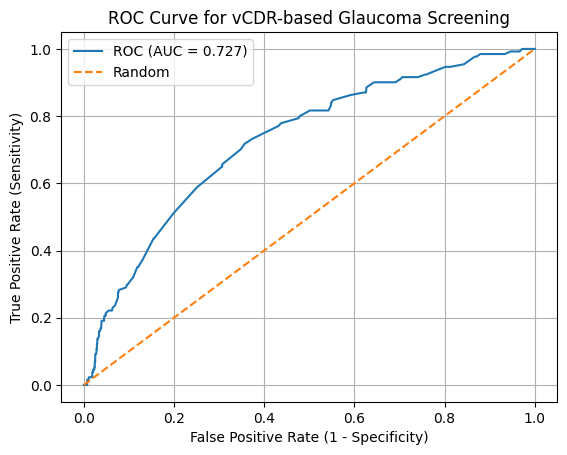

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve for vCDR-based Glaucoma Screening")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
youden_index = tpr - fpr
best_idx = np.argmax(youden_index)

best_threshold = thresholds[best_idx]
best_sens = tpr[best_idx]
best_spec = 1 - fpr[best_idx]

print(f"Optimal Threshold (Youden): {best_threshold:.3f}")
print(f"Sensitivity: {best_sens*100:.2f}%")
print(f"Specificity: {best_spec*100:.2f}%")


Optimal Threshold (Youden): 0.485
Sensitivity: 71.76%
Specificity: 64.36%


In [ ]:
def sensitivity_at_specificity(target_spec, fpr, tpr):
    spec = 1 - fpr
    idx = np.where(spec >= target_spec)[0]
    return tpr[idx[-1]] if len(idx) > 0 else 0.0

sens_90 = sensitivity_at_specificity(0.90, fpr, tpr)
sens_95 = sensitivity_at_specificity(0.95, fpr, tpr)

print(f"Sensitivity @ 90% Specificity: {sens_90*100:.2f}%")
print(f"Sensitivity @ 95% Specificity: {sens_95*100:.2f}%")


Sensitivity @ 90% Specificity: 29.77%
Sensitivity @ 95% Specificity: 21.37%


In [ ]:
import pandas as pd

baseline_df = pd.read_csv("Classical_Benchmark_Results.csv")

# Compute sensitivity/specificity from classical baseline
y_true_baseline = (baseline_df['vCDR_GT'] > 0.6).astype(int)
y_pred_baseline = (baseline_df['vCDR_Pred'] > 0.6).astype(int)

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_true_baseline, y_pred_baseline).ravel()
sens = tp / (tp + fn) * 100
spec = tn / (tn + fp) * 100
acc  = (tp + tn) / (tp + tn + fp + fn) * 100

print("Classical Baseline (Threshold 0.6)")
print(f"Sensitivity: {sens:.2f}% | Specificity: {spec:.2f}% | Accuracy: {acc:.2f}%")


FileNotFoundError: [Errno 2] No such file or directory: 'Classical_Benchmark_Results.csv'

In [ ]:
import pandas as pd

baseline_df = pd.read_csv("Classical_Benchmark_Results.csv")

# Compute sensitivity/specificity from classical baseline
y_true_baseline = (baseline_df['vCDR_GT'] > 0.5).astype(int)
y_pred_baseline = (baseline_df['vCDR_Pred'] > 0.5).astype(int)

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_true_baseline, y_pred_baseline).ravel()
sens = tp / (tp + fn) * 100
spec = tn / (tn + fp) * 100
acc  = (tp + tn) / (tp + tn + fp + fn) * 100

print("Classical Baseline (Threshold 0.5)")
print(f"Sensitivity: {sens:.2f}% | Specificity: {spec:.2f}% | Accuracy: {acc:.2f}%")
